## ***Read the cleaned data set***

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Read merged file
hf_df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

 ## ***Q9. Which risk factors are more prevalent among patients who died?***

Reasoning: Compare proportions of anaemia, diabetes, smoking, and hypertension among deceased vs surviving patients. Useful visuals: Grouped bar charts.
Why it matters: Helps identify which comorbidities are more common in the high-risk group.




               risk_factor  died_count  survived_count
0                 diabetes          13             453
1                     copd           4             229
2           mod_severe_ckd          24             450
3  cerebrovascular_disease           6             144
4                 dementia           1             114


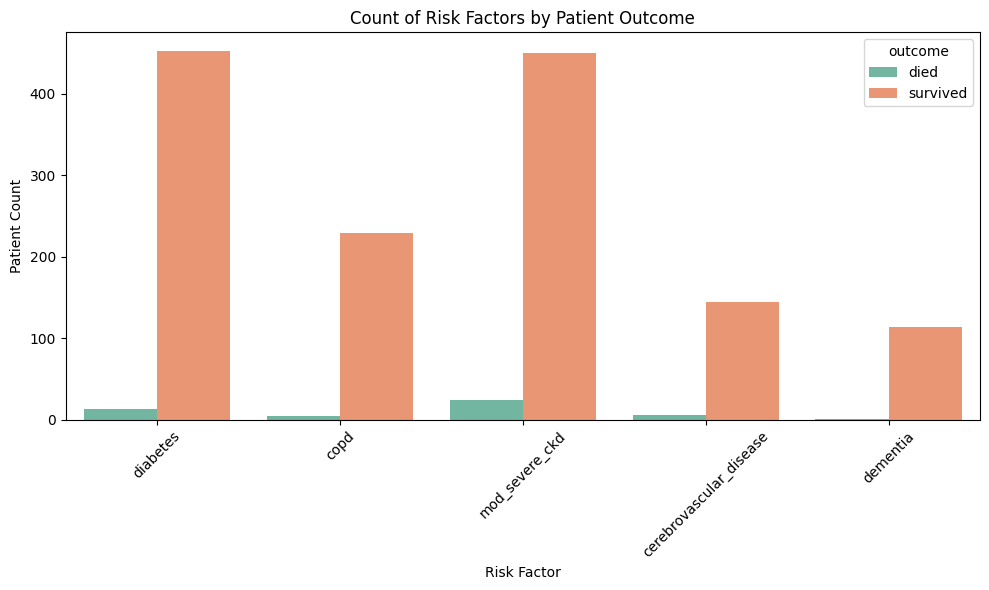

In [41]:
# 1) Merge on patient_id
df = hf_df.copy()

# 2) Define death outcome
df["died"] = (
    (df["in_hosp_outcome"].astype(str).str.lower() == "dead") |
    (df["mortality_28d"] == 1) |
    (df["death_3mo"] == 1) |
    (df["mortality_3mo"] == 1)
).astype(int)

# 3) Risk factors available in dataset
risk_factors = [
    "diabetes",
    "copd",
    "mod_severe_ckd",
    "cerebrovascular_disease",
    "dementia"
]

# Convert to binary counts: 0 = no, 1 = yes
for col in risk_factors:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
    df[col] = (df[col] > 0).astype(int)

# 4) Compare counts by outcome
comparison = []
for col in risk_factors:
    died_count = int(df.loc[df["died"] == 1, col].sum())
    survived_count = int(df.loc[df["died"] == 0, col].sum())

    comparison.append({
        "risk_factor": col,
        "died_count": died_count,
        "survived_count": survived_count
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df)

# 5) Prepare data for grouped bar chart
plot_df = comparison_df.melt(
    id_vars="risk_factor",
    value_vars=["died_count", "survived_count"],
    var_name="outcome",
    value_name="count"
)

plot_df["outcome"] = plot_df["outcome"].str.replace("_count", "", regex=False)

# 6) Plot grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="risk_factor", y="count", hue="outcome", palette="Set2")
plt.title("Count of Risk Factors by Patient Outcome")
plt.ylabel("Patient Count")
plt.xlabel("Risk Factor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## ***Q15. How does the recorded mortality rate vary by heart failure severity?***
##### *Reasoning: For this, I would use mortality_28d as the main outcome because it is a clear binary mortality indicator and is easier to compare across severity groups. As heart failure severity increases, mortality should rise, NYHA class or Killip grade is ordinal, therefore, the correct descriptive check is to compute mortality rate within each severity category and compare rates across categories*
##### *NYHA (Chronic heart Failure Severity) class I–IV describes functional severity of heart failure:*

        I: no limitation
        II: slight limitation
        III: marked limitation
        IV: symptoms even at rest
##### *For Killip Grade (Acute heart failure severity):*
        I: no heart failure
        II: mild/moderate heart failure
        III: pulmonary edema
        IV: cardiogenic shock


   nyha_class  patients  deaths  mortality_rate  mortality_rate_pct  \
0           2       353       3        0.008499            0.849858   
1           3      1039       7        0.006737            0.673725   
2           4       616      27        0.043831            4.383117   

  severity_label  
0        NYHA II  
1       NYHA III  
2        NYHA IV  


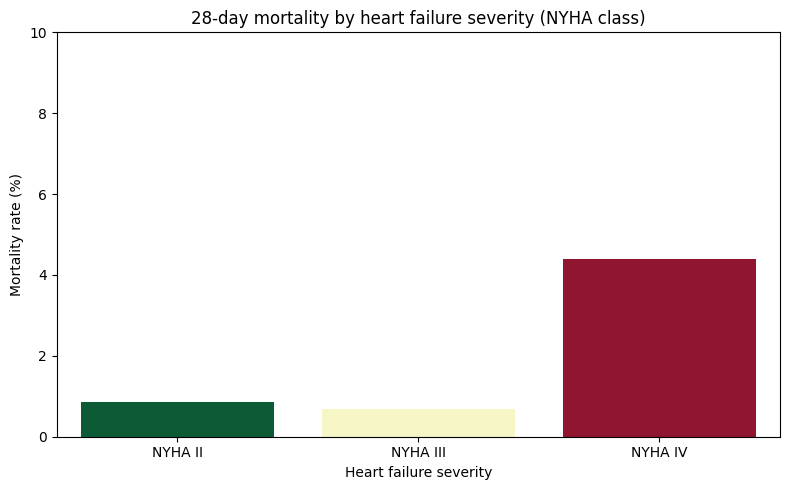

In [ ]:
# Keep only needed columns
severity_df = hf_df[["patient_id", "nyha_cardiac_function_classification", "killip_grade", "mortality_28d", "in_hosp_outcome"]].copy()

# Clean severity columns
severity_df["nyha_class"] = pd.to_numeric(severity_df["nyha_cardiac_function_classification"], errors="coerce")
severity_df["killip"] = pd.to_numeric(severity_df["killip_grade"], errors="coerce")

# Clean outcome columns
severity_df["mortality_28d"] = pd.to_numeric(severity_df["mortality_28d"], errors="coerce").fillna(0)
severity_df["in_hospital_dead"] = severity_df["in_hosp_outcome"].astype(str).str.strip().str.lower().isin(["dead", "death", "died"])

# Remove missing severity values
severity_df = severity_df.dropna(subset=["nyha_class", "mortality_28d"])

# Summary by NYHA class
nyha_summary = (
    severity_df.groupby("nyha_class")
      .agg(
          patients=("patient_id", "count"),
          deaths=("mortality_28d", "sum"),
          mortality_rate=("mortality_28d", "mean")
      )
      .reset_index()
)

nyha_summary["mortality_rate_pct"] = nyha_summary["mortality_rate"] * 100
nyha_summary["severity_label"] = nyha_summary["nyha_class"].map({
    1: "NYHA I",
    2: "NYHA II",
    3: "NYHA III",
    4: "NYHA IV"
})

print(nyha_summary.sort_values("nyha_class"))

plt.figure(figsize=(8, 5))

sns.barplot(
    data=nyha_summary,
    x="severity_label",
    y="mortality_rate_pct",
    hue=nyha_summary.index,
    dodge=False,
    legend=False,
    palette="RdYlGn_r"
)

plt.title("28-day mortality by heart failure severity (NYHA class)")
plt.xlabel("Heart failure severity")
plt.ylabel("Mortality rate (%)")
plt.ylim(0, max(nyha_summary["mortality_rate_pct"].max() * 1.3, 10))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### *Second plot using Killip Category*

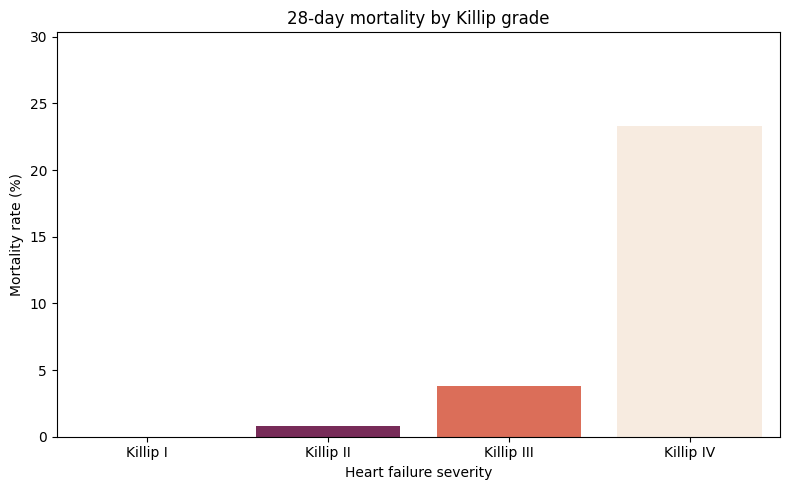

In [49]:
killip_summary = (
    severity_df.groupby("killip")
      .agg(
          patients=("patient_id", "count"),
          deaths=("mortality_28d", "sum"),
          mortality_rate=("mortality_28d", "mean")
      )
      .reset_index()
)

killip_summary["mortality_rate_pct"] = killip_summary["mortality_rate"] * 100
killip_summary["severity_label"] = killip_summary["killip"].map({
    1: "Killip I",
    2: "Killip II",
    3: "Killip III",
    4: "Killip IV"
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=killip_summary,
    x="severity_label",
    y="mortality_rate_pct",
    hue=killip_summary.index,
    dodge=False,
    legend=False,
    palette="rocket"
)

plt.title("28-day mortality by Killip grade")
plt.xlabel("Heart failure severity")
plt.ylabel("Mortality rate (%)")
plt.ylim(0, max(killip_summary["mortality_rate_pct"].max() * 1.3, 10))
plt.tight_layout()
plt.show()

## ***Q12. What percentage of patients died at each recorded follow-up point?***
##### *Reasoning:*
##### *It is answered by comparing the proportion of patients who died at each recorded follow-up point, rather than simply counting deaths.The merged dataset contains time-specific survival indicators, including: in-hospital death, 28-day mortality, 3-month mortality*
##### *The approach we followed is:*
    1. convert each mortality indicator to a binary flag (0 = alive, 1 = dead)
    2. calculate the percentage dead at each follow-up point
    3. plot the percentages side by side to show how mortality rises or falls over time


     follow_up  deaths  total  mortality_pct
0  In hospital      11   1901       0.578643
1       28-day      37   2008       1.842629
2      3-month      57   2008       2.838645


/var/folders/3r/xw690fd12mj11sp07vyw1fc00000gn/T/ipykernel_73911/250798720.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


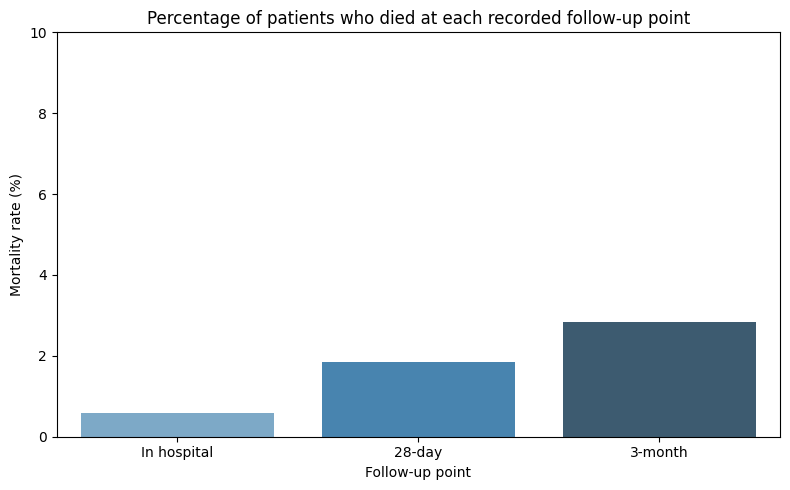

In [44]:
# identify the mortality columns available in the dataset
# these are the follow-up points we can compare
# in_hosp_outcome, mortality_28d, mortality_3mo

# clean the binary outcome columns
def to_binary_dead(value):
    if pd.isna(value):
        return pd.NA
    s = str(value).strip().lower()
    if s in ["dead", "death", "died", "1", "true", "yes"]:
        return 1
    elif s in ["alive", "0", "false", "no"]:
        return 0
    else:
        return pd.NA

hf_df["in_hospital_dead"] = hf_df["in_hosp_outcome"].apply(to_binary_dead)
hf_df["mortality_28d"] = pd.to_numeric(hf_df["mortality_28d"], errors="coerce")
hf_df["mortality_3mo"] = pd.to_numeric(hf_df["mortality_3mo"], errors="coerce")

# choose the recorded follow-up points for comparison
followup_map = {
    "In hospital": "in_hospital_dead",
    "28-day": "mortality_28d",
    "3-month": "mortality_3mo"
}

summary = []

for label, col in followup_map.items():
    s = hf_df[col].dropna()
    if s.empty:
        continue

    deaths = s.sum()
    total = len(s)
    pct = (deaths / total) * 100

    summary.append({
        "follow_up": label,
        "deaths": int(deaths),
        "total": int(total),
        "mortality_pct": pct
    })

summary_df = pd.DataFrame(summary)

print(summary_df)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=summary_df,
    x="follow_up",
    y="mortality_pct",
    palette="Blues_d"
)

plt.title("Percentage of patients who died at each recorded follow-up point")
plt.xlabel("Follow-up point")
plt.ylabel("Mortality rate (%)")
plt.ylim(0, max(summary_df["mortality_pct"].max() * 1.3, 10))
plt.tight_layout()
plt.show()